# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops (From DataCamp)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.

A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:

- `"N"`: Nitrogen content ratio in the soil
- `"P"`: Phosphorous content ratio in the soil
- `"K"`: Potassium content ratio in the soil
- `"pH"` value of the soil
- `"crop"`: categorical values that contain various crops (target variable).

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  

In this project, you will build multi-class classification models to predict the type of `"crop"` and identify the single most importance feature for predictive performance.

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load the dataset
crops = pd.read_csv("datasets/soil_measures.csv")

print(crops.head())
print(crops.shape)

    N   P   K        ph  crop
0  90  42  43  6.502985  rice
1  85  58  41  7.038096  rice
2  60  55  44  7.840207  rice
3  74  35  40  6.980401  rice
4  78  42  42  7.628473  rice
(2200, 5)


In [4]:
# Chech missing values
print(crops.isnull().sum())

N       0
P       0
K       0
ph      0
crop    0
dtype: int64


In [5]:
# Check crop types
print(crops['crop'].value_counts())

crop
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [10]:
# Split the data into features and target variable
X = crops.drop('crop', axis=1)
y = crops['crop']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Evaluate feature performance
performance = {}
    
# Loop through each feature
for feature in X.columns:
    # Train a multiclass classifier using only the i-th feature
    clf = LogisticRegression(max_iter=10000)
    clf.fit(X_train[[feature]], y_train)

    # Predict on the test set
    y_pred = clf.predict(X_test[[feature]])

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_pred)
    performance[feature] = accuracy

print(performance)

{'N': 0.1431818181818182, 'P': 0.18181818181818182, 'K': 0.24772727272727274, 'ph': 0.09772727272727273}


In [16]:
# create a variable called best_predictive_feature, which:
# Should be a dictionary containing the best predictive feature name as a key and the evaluation score (for the metric you chose) as the value.
best_predictive_feature = {max(performance, key=performance.get): max(performance.values())}
best_predictive_feature

{'K': 0.24772727272727274}

## Additional Work

In [17]:
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [18]:
X = crops.drop('crop', axis=1).values
y = crops['crop'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Baseline models

In [19]:
# Imports
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [20]:
# Create pipelines
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

pipelines = {
    name: Pipeline([('scaler', StandardScaler()), ('model', model)]) 
        for name, model in models.items()
}

Logistic Regression: Mean Accuracy = 0.6642, Std = 0.0274
KNN: Mean Accuracy = 0.7477, Std = 0.0217
Decision Tree: Mean Accuracy = 0.7699, Std = 0.0201


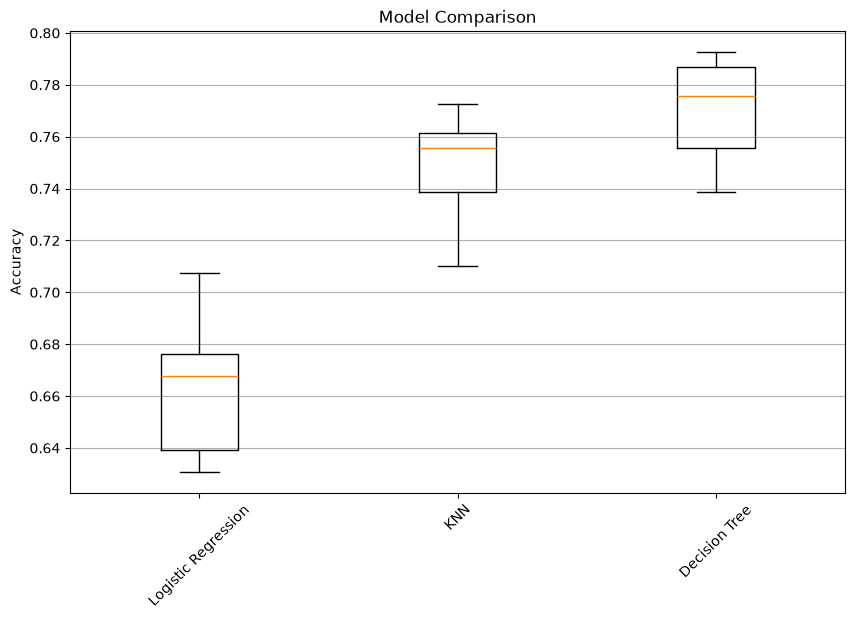

In [28]:
results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
    results[name] = cv_scores
    print(f"{name}: Mean Accuracy = {cv_scores.mean():.4f}, Std = {cv_scores.std():.4f}")
    
# Plot the results
plt.figure(figsize=(10, 6))
plt.boxplot(results.values())
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(range(1, len(results.keys()) + 1), results.keys(), rotation=45)
plt.grid(axis='y', )
plt.show()

In [23]:
# Winner model parameters
print(DecisionTreeClassifier().get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [25]:
# Hyperparameter tuning for Decision Tree
from sklearn.model_selection import GridSearchCV

dt_pipeline = Pipeline([('scaler', StandardScaler()), 
                        ('dt', DecisionTreeClassifier(random_state=42))])

param_grid = {
    'dt__max_depth': [None, 5, 10, 15],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf': [1, 2, 5,10],
    'dt__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(dt_pipeline, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Best cross-validation accuracy: 0.7926


              precision    recall  f1-score   support

       apple       0.37      0.35      0.36        20
      banana       1.00      1.00      1.00        20
   blackgram       0.59      0.85      0.69        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.72      0.90      0.80        20
      coffee       1.00      0.90      0.95        20
      cotton       1.00      1.00      1.00        20
      grapes       0.38      0.40      0.39        20
        jute       0.60      0.90      0.72        20
 kidneybeans       0.80      1.00      0.89        20
      lentil       0.47      0.35      0.40        20
       maize       0.91      1.00      0.95        20
       mango       0.87      0.65      0.74        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       0.83      0.95      0.88        20
   muskmelon       0.55      0.55      0.55        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

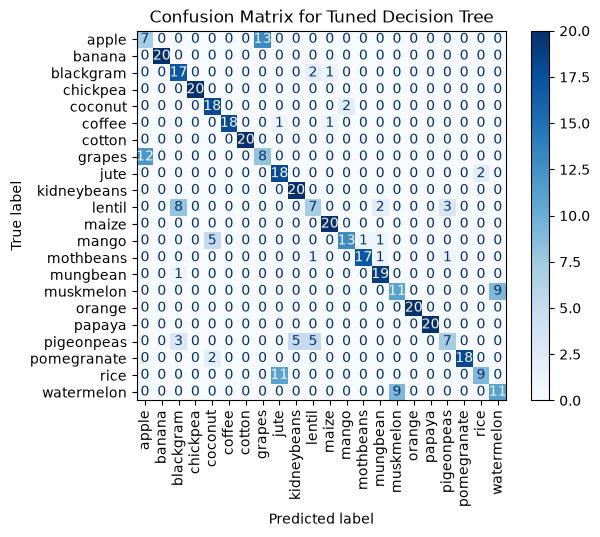

In [30]:
# Use tuned model
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(best_dt_model, X_test, y_test, display_labels=best_dt_model.classes_, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Decision Tree')
plt.xticks(rotation=90)
plt.show()